In [7]:
import cv2
import numpy as np
import os

class VideoPreprocessor:
    def __init__(self, video_path: str):
        self.video_path = video_path
        self.cap = cv2.VideoCapture(video_path)
        
        if not self.cap.isOpened():
            raise ValueError(f"Не удалось открыть видео: {video_path}")
        
        # Метаданные
        self.fps = self.cap.get(cv2.CAP_PROP_FPS)
        self.total_frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))
        self.duration_ms = int((self.total_frames / self.fps) * 1000)
        
        # Параметры
        self.window_size_ms = 1000  # 1 секунда
        self.sharpness_threshold = 100.0
        self.rotation_code = cv2.ROTATE_90_COUNTERCLOCKWISE
    
    def calculate_sharpness(self, frame: np.ndarray) -> float:
        """Laplacian variance"""
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        return laplacian.var()
    
    def enhance_frame(self, frame: np.ndarray) -> np.ndarray:
        """CLAHE + Gamma + Bilateral"""
        # CLAHE
        lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        lab[:,:,0] = clahe.apply(lab[:,:,0])
        frame = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
        
        # Gamma
        gamma = 0.9
        inv_gamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** (1.0 / inv_gamma) * 255)
                          for i in np.arange(0, 256)]).astype("uint8")
        frame = cv2.LUT(frame, table)
        
        # Bilateral
        frame = cv2.bilateralFilter(frame, d=5, sigmaColor=50, sigmaSpace=50)
        
        return frame
    
    def process(self) -> list:
        """
        Основной пайплайн:
        1. Читаем видео
        2. Поворачиваем
        3. Разбиваем на окна
        4. В каждом окне выбираем лучший кадр
        5. Улучшаем
        6. Возвращаем список (timestamp, frame, sharpness)
        """
        best_frames = []
        buffer = []  # Кадры в текущем окне
        last_flush_ts = 0
        
        frame_idx = 0
        
        while self.cap.isOpened():
            ret, frame = self.cap.read()
            if not ret:
                break
            
            # 1. Поворот
            frame = cv2.rotate(frame, self.rotation_code)
            
            # 2. Timestamp
            ts_ms = int(self.cap.get(cv2.CAP_PROP_POS_MSEC))
            
            # 3. Sharpness
            sharpness = self.calculate_sharpness(frame)
            
            # 4. Фильтруем размытые
            if sharpness > self.sharpness_threshold:
                buffer.append((ts_ms, sharpness, frame.copy()))
            
            # 5. Каждое окно → выбираем лучшего
            if ts_ms - last_flush_ts >= self.window_size_ms:
                if buffer:
                    # Лучший по sharpness
                    best_ts, best_score, best_img = max(buffer, key=lambda x: x[1])
                    
                    # Улучшаем
                    enhanced = self.enhance_frame(best_img)
                    best_frames.append((best_ts, enhanced, best_score))
                
                # Сброс
                buffer = []
                last_flush_ts = ts_ms
            
            frame_idx += 1
        
        # Последний кадр
        self.cap.release()
        
        return best_frames
    
    def save_frames(self, frames: list, output_dir: str):
        """Сохраняем кадры для отладки"""
        os.makedirs(output_dir, exist_ok=True)
        
        for i, (ts, frame, score) in enumerate(frames):
            filename = f"frame_{ts}_score_{score:.1f}.jpg"
            filepath = os.path.join(output_dir, filename)
            cv2.imwrite(filepath, frame)
        
        print(f"✅ Сохранено {len(frames)} кадров в {output_dir}")


# Использование
if __name__ == "__main__":
    preprocessor = VideoPreprocessor("data/25_12-20.mp4")
    frames = preprocessor.process()
    preprocessor.save_frames(frames, "extracted_frames")
    
    print(f"\n📊 Статистика:")
    print(f"  Всего кадров: {len(frames)}")
    print(f"  Средняя чёткость: {np.mean([s for _,_,s in frames]):.1f}")
    print(f"  Диапазон: {min([s for _,_,s in frames]):.1f} – {max([s for _,_,s in frames]):.1f}")

✅ Сохранено 40 кадров в extracted_frames

📊 Статистика:
  Всего кадров: 40
  Средняя чёткость: 1324.9
  Диапазон: 822.7 – 3254.9


In [11]:
import cv2
import json
import os
import re
import random
from pathlib import Path
from ultralytics import YOLO
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 🔧 НАСТРОЙКИ
MODEL_PATH = r"D:\hak\Lenta Tech\Lenta_Tech_detector\runs\detect\models\price_tag_v1\weights\best.pt"
INPUT_DIR = "extracted_frames"
OUTPUT_JSON = "detections.json"
NUM_SAMPLES_TO_SHOW = 4  # Сколько случайных кадров вывести

random.seed(42)  # Фиксируем seed, чтобы превью не менялись при повторных запусках

print(f"📦 Загрузка модели: {MODEL_PATH}")
model = YOLO(MODEL_PATH, verbose=False)

frame_files = sorted(list(Path(INPUT_DIR).glob("*.jpg")))
if not frame_files:
    raise FileNotFoundError(f"❌ Папка {INPUT_DIR} пуста. Запусти Ячейку 1.")

all_detections = []
print(f"🔍 Инференс на {len(frame_files)} кадрах (conf=0.05)...")

for f_path in tqdm(frame_files, desc="YOLO Inference"):
    img = cv2.imread(str(f_path))
    if img is None: continue
    
    fname = f_path.name
    
    # 🔒 Надёжный парсинг таймстемпа (защита от краша, если имя файла изменится)
    ts_match = re.search(r"_ts(\d+)", fname)
    ts_ms = int(ts_match.group(1)) if ts_match else 0
    
    results = model(img, conf=0.05, verbose=False)
    
    frame_det = {
        "filename": fname,
        "timestamp_ms": ts_ms,
        "boxes": []
    }
    
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        conf = float(box.conf)
        frame_det["boxes"].append({
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "confidence": conf
        })
        
    all_detections.append(frame_det)

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(all_detections, f, indent=2, ensure_ascii=False)

total_boxes = sum(len(d["boxes"]) for d in all_detections)
print(f"✅ Инференс завершён. Найдено {total_boxes} объектов. Результат в {OUTPUT_JSON}")

# 🖼️ ВИЗУАЛИЗАЦИЯ СЛУЧАЙНЫХ КАДРОВ С БОКСАМИ
print(f"\n🎨 Генерация превью для {NUM_SAMPLES_TO_SHOW} случайных кадров...")
os.makedirs("preview_boxes", exist_ok=True)

# Берём только кадры, где модель что-то нашла
detected_frames = [d for d in all_detections if len(d["boxes"]) > 0]

if not detected_frames:
    print("⚠️ Детекции не найдены, визуализация пропущена.")
else:
    samples = random.sample(detected_frames, min(NUM_SAMPLES_TO_SHOW, len(detected_frames)))
    
    fig, axes = plt.subplots(1, len(samples), figsize=(5*len(samples), 5))
    if len(samples) == 1: 
        axes = [axes]
        
    for ax, det in zip(axes, samples):
        img_path = Path(INPUT_DIR) / det["filename"]
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        
        for box in det["boxes"]:
            x1, y1, x2, y2 = box["x1"], box["y1"], box["x2"], box["y2"]
            conf = box["confidence"]
            # Рисуем прямоугольник
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='#00FF00', facecolor='none')
            ax.add_patch(rect)
            # Подпись с уверенностью
            ax.text(x1, y1-5, f"{conf:.2f}", color='#00FF00', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', pad=2))
            
        ax.set_title(det["filename"].replace(".jpg", ""), fontsize=9)
        ax.axis('off')
        
    plt.tight_layout()
    plt.savefig("preview_boxes/random_detections.png", dpi=150, bbox_inches='tight')
    print("📸 Превью сохранено в: preview_boxes/random_detections.png")
    plt.show()

📦 Загрузка модели: D:\hak\Lenta Tech\Lenta_Tech_detector\runs\detect\models\price_tag_v1\weights\best.pt
🔍 Инференс на 40 кадрах (conf=0.05)...


YOLO Inference: 100%|██████████| 40/40 [00:03<00:00, 10.80it/s]


✅ Инференс завершён. Найдено 237 объектов. Результат в detections.json

🎨 Генерация превью для 4 случайных кадров...
📸 Превью сохранено в: preview_boxes/random_detections.png


<Figure size 2000x500 with 4 Axes>

In [13]:
import cv2
import json
import os
from pathlib import Path
from tqdm import tqdm

# 🔧 НАСТРОЙКИ
DETECTIONS_JSON = "detections.json"
INPUT_DIR = "extracted_frames"
OUTPUT_DIR = "crops"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📂 Загрузка детекций из {DETECTIONS_JSON}...")
with open(DETECTIONS_JSON, "r", encoding="utf-8") as f:
    detections = json.load(f)

saved_count = 0
print(f"✂️ Вырезка кропов и расчёт исходных координат...")

for det in tqdm(detections, desc="Cropping"):
    fname = det["filename"]
    img_path = Path(INPUT_DIR) / fname
    img = cv2.imread(str(img_path))
    if img is None: continue
    
    h_rot, w_rot, _ = img.shape  # h_rot == высота исходного видео, w_rot == ширина
    
    for box in det["boxes"]:
        x1_r, y1_r, x2_r, y2_r = box["x1"], box["y1"], box["x2"], box["y2"]
        
        # Базовый фильтр площади
        if (x2_r - x1_r) * (y2_r - y1_r) < 1500: continue
            
        crop = img[y1_r:y2_r, x1_r:x2_r]
        if crop.size == 0: continue
        
        # 🔄 ТРАНСФОРМАЦИЯ КООРДИНАТ В ИСХОДНУЮ ОРИЕНТАЦИЮ
        # Поворот был 90° CCW: (x_orig, y_orig) -> (y_orig, W_orig - x_orig)
        # Обратное преобразование (90° CW):
        x1_o = h_rot - y2_r
        y1_o = x1_r
        x2_o = h_rot - y1_r
        y2_o = x2_r
        
        box["x1_orig"] = x1_o
        box["y1_orig"] = y1_o
        box["x2_orig"] = x2_o
        box["y2_orig"] = y2_o
        
        # Сохранение кропа
        crop_name = f"{fname.replace('.jpg', '')}_bbox_{x1_r}_{y1_r}_{x2_r}_{y2_r}.jpg"
        cv2.imwrite(os.path.join(OUTPUT_DIR, crop_name), crop)
        saved_count += 1

# Сохраняем обновлённые детекции с исходными координатами
with open("detections_with_orig_coords.json", "w", encoding="utf-8") as f:
    json.dump(detections, f, indent=2, ensure_ascii=False)

print(f"✅ Готово! Сохранено {saved_count} кропов в {OUTPUT_DIR}/")
print("📦 Файл detections_with_orig_coords.json готов для генерации CSV (координаты уже в исходной ориентации).")

📂 Загрузка детекций из detections.json...
✂️ Вырезка кропов и расчёт исходных координат...


Cropping: 100%|██████████| 40/40 [00:01<00:00, 20.57it/s]

✅ Готово! Сохранено 237 кропов в crops/
📦 Файл detections_with_orig_coords.json готов для генерации CSV (координаты уже в исходной ориентации).


In [22]:
# OCR PREPROCESSING — imports and helpers
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

CROPS_DIR = 'crops'
crops = sorted(list(Path(CROPS_DIR).glob('*.jpg')))
print(f'🔎 Найдено {len(crops)} кропов в {CROPS_DIR}/')

def load_crop(path_or_name):
    p = Path(path_or_name) if isinstance(path_or_name, (str, Path)) else path_or_name
    if not p.exists():
        raise FileNotFoundError(p)
    img = cv2.imread(str(p))
    if img is None:
        raise ValueError(f'Не удалось прочитать изображение: {p}')
    return img

# Quick preview: first 5 filenames
for i, p in enumerate(crops[:5]):
    print(f'  {i}: {p.name}')

🔎 Найдено 237 кропов в crops/
  0: frame_10551_score_986.4_bbox_0_3027_356_3269.jpg
  1: frame_10551_score_986.4_bbox_1302_3072_1560_3272.jpg
  2: frame_10551_score_986.4_bbox_1761_3007_1980_3216.jpg
  3: frame_10551_score_986.4_bbox_1862_1539_2091_1767.jpg
  4: frame_10551_score_986.4_bbox_243_1401_542_1678.jpg


In [23]:
# 1) Grayscale
def to_grayscale(img):
    """Convert BGR -> GRAY (uint8)"""
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Debug quick test (uncomment to run)
# img = load_crop(crops[0])
# g = to_grayscale(img)
# print('grayscale shape', g.shape, g.dtype)

In [24]:
# 2) CLAHE contrast enhancement
def clahe_enhance(img, clipLimit=2.0, tileGridSize=(8,8)):
    """Apply CLAHE on L channel and return BGR image"""
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

# Debug: print types after processing
# img = load_crop(crops[0])
# print(clahe_enhance(img).shape)

In [25]:
# 3) Adaptive threshold (binarization)
def adaptive_threshold(img, maxValue=255, method=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                       thresholdType=cv2.THRESH_BINARY, blockSize=15, C=10):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if blockSize % 2 == 0:
        blockSize += 1
    th = cv2.adaptiveThreshold(gray, maxValue, method, thresholdType, blockSize, C)
    return th

# Note: output is single-channel binary image

In [26]:
# 4) Denoise (fastNlMeans) — for colored crops
def denoise(img, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21):
    """Keep BGR colors, reduce noise."""
    return cv2.fastNlMeansDenoisingColored(img, None, h, hColor, templateWindowSize, searchWindowSize)

# 5) Sharpen
def sharpen(img):
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
    return cv2.filter2D(img, -1, kernel)

# 6) Upscale (for OCR engines that benefit from larger input)
def upscale(img, scale=2):
    h, w = img.shape[:2]
    return cv2.resize(img, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)

In [27]:
# Aggregate: apply all preprocessing methods and return dict
def apply_all_preprocessing(img):
    results = {}
    results['original'] = img
    results['grayscale'] = to_grayscale(img)
    results['clahe'] = clahe_enhance(img)
    results['denoise'] = denoise(img)
    results['sharpen'] = sharpen(img)
    results['upscale'] = upscale(img, scale=2)
    try:
        results['adaptive_thresh'] = adaptive_threshold(img)
    except Exception as e:
        results['adaptive_thresh'] = None
    return results

# Helper to convert for display in matplotlib (RGB / gray)
def to_display(img):
    if img is None:
        return None
    if len(img.shape) == 2:
        return img
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

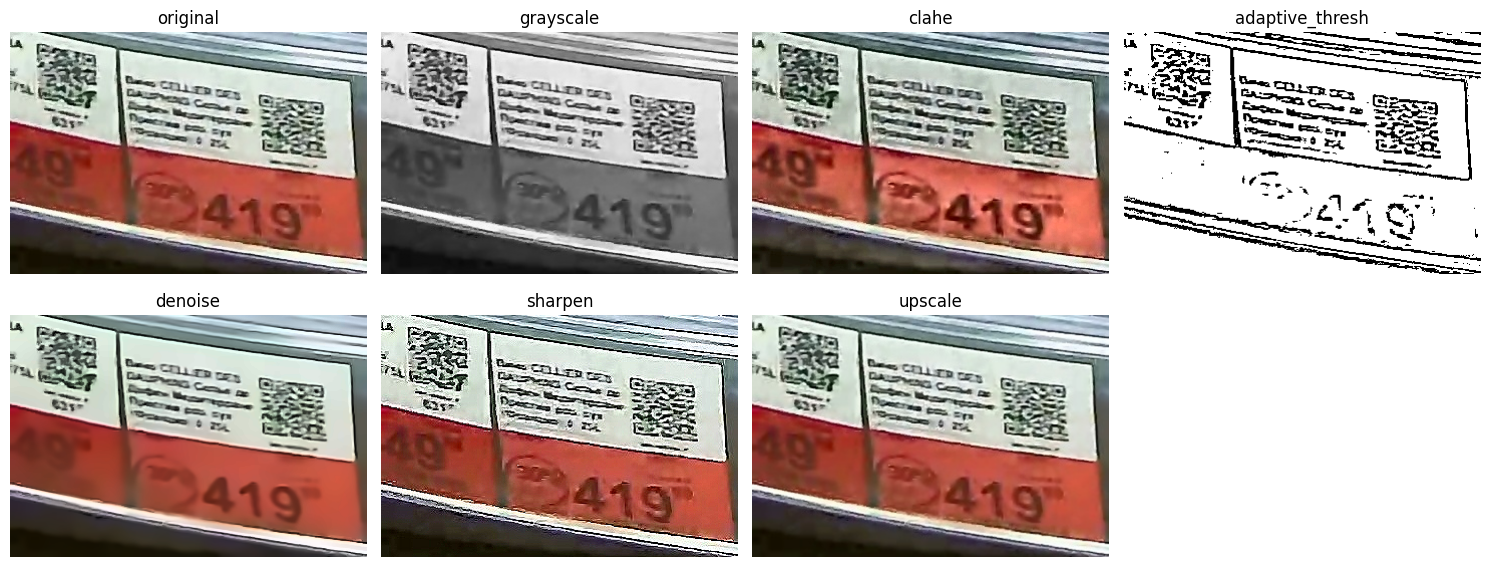

In [31]:
# Visualization: show original + all preprocessing variants (grid)
def show_variants(img_path, methods_order=None, figsize=(15,6), save_to=None):
    img = load_crop(img_path)
    res = apply_all_preprocessing(img)
    if methods_order is None:
        methods_order = ['original','grayscale','clahe','adaptive_thresh','denoise','sharpen','upscale']
    n = len([m for m in methods_order if res.get(m) is not None])
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax in axes: ax.axis('off')
    i = 0
    for m in methods_order:
        if res.get(m) is None: continue
        disp = to_display(res[m])
        ax = axes[i]
        if disp is None:
            ax.set_title(m)
            i += 1
            continue
        if len(disp.shape) == 2:
            ax.imshow(disp, cmap='gray')
        else:
            ax.imshow(disp)
        ax.set_title(m)
        ax.axis('off')
        i += 1
    plt.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=150, bbox_inches='tight')
        print(f'💾 Сохранено превью: {save_to}')
    plt.show()

# Example usage (uncomment and run):
show_variants(crops[0])

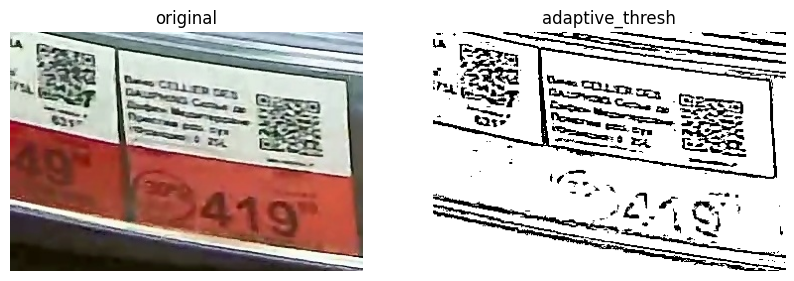

In [30]:
# Быстрый переключатель: показать только оригинал + выбранный метод рядом
def show_method_compare(img_path, method='clahe'):
    img = load_crop(img_path)
    res = apply_all_preprocessing(img)
    left = to_display(res['original'])
    right = to_display(res.get(method))
    if right is None:
        print(f'Метод {method} вернул None')
        return
    fig, axes = plt.subplots(1,2,figsize=(10,5))
    axes[0].imshow(left); axes[0].set_title('original'); axes[0].axis('off')
    if len(right.shape) == 2:
        axes[1].imshow(right, cmap='gray')
    else:
        axes[1].imshow(right)
    axes[1].set_title(method); axes[1].axis('off')
    plt.show()

show_method_compare(crops[0], method='adaptive_thresh')

# Multi-OCR pipeline for whole price-tag crops
# Запускаем OCR на whole-tag crops, чтобы сравнить PaddleOCR, EasyOCR и pytesseract.

In [47]:
import pandas as pd
import re
from IPython.display import display

try:
    from paddleocr import PaddleOCR
    paddle_available = True
except Exception as e:
    paddle_available = False
    paddle_error = str(e)

try:
    import easyocr
    easyocr_available = True
except Exception as e:
    easyocr_available = False
    easyocr_error = str(e)

try:
    import pytesseract
    pytesseract_available = True
except Exception as e:
    pytesseract_available = False
    pytesseract_error = str(e)

USE_PADDLE = False  # Set to True only if PaddleOCR compatibility is confirmed

print('🧪 OCR engines status:')
print(f'  PaddleOCR import available: {paddle_available}')
print(f'  EasyOCR:   {easyocr_available}')
print(f'  Tesseract: {pytesseract_available}')
if not paddle_available:
    print('  PaddleOCR import error:', paddle_error)
if not easyocr_available:
    print('  EasyOCR error:', easyocr_error)
if not pytesseract_available:
    print('  pytesseract error:', pytesseract_error)

OCR_ENGINES = []
if paddle_available and USE_PADDLE:
    try:
        paddle_model = PaddleOCR(use_textline_orientation=True, lang='ru')
        # Run a quick compatibility check on a blank image.
        try:
            _ = paddle_model.predict(np.zeros((32, 32, 3), dtype=np.uint8))
            OCR_ENGINES.append('paddle')
        except Exception as e:
            paddle_model = None
            paddle_available = False
            paddle_error = str(e)
            print('  PaddleOCR compatibility check failed:', paddle_error)
    except Exception as e:
        paddle_model = None
        paddle_available = False
        paddle_error = str(e)
        print('  PaddleOCR initialization failed:', paddle_error)
else:
    paddle_model = None
    if paddle_available and not USE_PADDLE:
        print('  PaddleOCR is available but disabled by default due to environment compatibility. Set USE_PADDLE = True to enable.')

if easyocr_available:
    easyocr_reader = easyocr.Reader(['ru', 'en'], gpu=False)
    OCR_ENGINES.append('easyocr')
else:
    easyocr_reader = None

if pytesseract_available:
    OCR_ENGINES.append('tesseract')


Using CPU. Note: This module is much faster with a GPU.


🧪 OCR engines status:
  PaddleOCR import available: True
  EasyOCR:   True
  Tesseract: False
  pytesseract error: No module named 'pytesseract'
  PaddleOCR is available but disabled by default due to environment compatibility. Set USE_PADDLE = True to enable.


In [52]:
def ocr_with_paddle(img, model):
    if model is None:
        return '', 0.0, []
    try:
        if hasattr(model, 'predict'):
            result = model.predict(img)
        else:
            result = model.ocr(img)
    except Exception:
        return '', 0.0, []
    texts = []
    confs = []
    for line in result:
        if len(line) < 2:
            continue
        line_text = line[1][0]
        line_conf = line[1][1]
        texts.append(line_text)
        confs.append(line_conf)
    text = ' '.join(texts).strip()
    avg_conf = float(np.mean(confs)) if confs else 0.0
    return text, avg_conf, confs


def ocr_with_easyocr(img, reader):
    if reader is None:
        return '', 0.0, []
    try:
        input_img = img
        if len(input_img.shape) == 3:
            input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
        result = reader.readtext(input_img, detail=1, paragraph=False)
    except Exception:
        return '', 0.0, []
    texts = []
    confs = []
    for item in result:
        if len(item) < 3:
            continue
        texts.append(item[1])
        confs.append(float(item[2]) if item[2] is not None else 0.0)
    text = ' '.join(texts).strip()
    avg_conf = float(np.mean(confs)) if confs else 0.0
    return text, avg_conf, confs


def ocr_with_tesseract(img):
    if not pytesseract_available:
        return '', 0.0, []
    try:
        gray = img if len(img.shape) == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if gray.dtype != np.uint8:
            gray = gray.astype(np.uint8)
        config = '--oem 3 --psm 6'
        try:
            text = pytesseract.image_to_string(gray, lang='rus+eng', config=config)
        except Exception:
            text = pytesseract.image_to_string(gray, lang='eng', config=config)
        text = re.sub(r'[\r\n]+', ' ', text).strip()
        confs = []
        try:
            data = pytesseract.image_to_data(gray, lang='rus+eng', config=config, output_type=pytesseract.Output.DICT)
            confs = [float(c) for c in data['conf'] if c.strip() != '-1']
        except Exception:
            confs = []
        avg_conf = float(np.mean(confs)) if confs else 0.0
        return text, avg_conf, confs
    except Exception:
        return '', 0.0, []


def text_quality_metrics(text):
    text_clean = re.sub(r'\s+', ' ', text).strip()
    if not text_clean:
        return {
            'text': text_clean,
            'text_length': 0,
            'digit_count': 0,
            'currency_match': 0,
            'price_match': 0,
            'meaningful_score': 0
        }
    digit_count = len(re.findall(r'\d', text_clean))
    currency_match = 1 if re.search(r'₽|руб|р\.|р\b|rb\b|r\b|p\b|\$', text_clean, re.I) else 0
    price_match = 1 if re.search(r'\b\d[\d\s,\.]*\d\b', text_clean) else 0
    meaningful_score = len(re.sub(r'[^\w\dА-Яа-я]', ' ', text_clean).strip())
    return {
        'text': text_clean,
        'text_length': len(text_clean),
        'digit_count': digit_count,
        'currency_match': currency_match,
        'price_match': price_match,
        'meaningful_score': meaningful_score
    }


def run_multi_ocr_on_crop(img_path):
    img = load_crop(img_path)
    variants = apply_all_preprocessing(img)
    rows = []

    for method, variant in variants.items():
        if variant is None:
            continue
        for engine in OCR_ENGINES:
            if engine == 'paddle':
                text, avg_conf, confs = ocr_with_paddle(variant, paddle_model)
                engine_name = 'PaddleOCR'
            elif engine == 'easyocr':
                text, avg_conf, confs = ocr_with_easyocr(variant, easyocr_reader)
                engine_name = 'EasyOCR'
            elif engine == 'tesseract':
                text, avg_conf, confs = ocr_with_tesseract(variant)
                engine_name = 'pytesseract'
            else:
                continue

            metrics = text_quality_metrics(text)
            rows.append({
                'crop_name': Path(img_path).name,
                'method': method,
                'engine': engine_name,
                'ocr_text': metrics['text'],
                'confidence': avg_conf,
                'text_length': metrics['text_length'],
                'digit_count': metrics['digit_count'],
                'currency_match': metrics['currency_match'],
                'price_match': metrics['price_match'],
                'meaningful_score': metrics['meaningful_score'],
                'regex_quality': metrics['currency_match'] * 20 + metrics['price_match'] * 10 + metrics['digit_count']
            })

    return pd.DataFrame(rows)


def rank_ocr_results(df):
    if df.empty:
        return df
    ranked = df.copy()
    ranked['combined_score'] = (
        ranked['currency_match'] * 20.0 +
        ranked['price_match'] * 10.0 +
        ranked['regex_quality'] * 1.5 +
        ranked['meaningful_score'] * 0.5 +
        ranked['confidence'] * 0.2
    )
    ranked = ranked.sort_values(
        ['combined_score', 'currency_match', 'price_match', 'text_length', 'confidence'],
        ascending=False
    )
    return ranked.reset_index(drop=True)

In [53]:
def show_crop_ocr_summary(img_path, top_n=5, methods=None, engines=None):
    df = run_multi_ocr_on_crop(img_path)
    ranked = rank_ocr_results(df)

    if methods is not None:
        ranked = ranked[ranked['method'].isin(methods)]
    if engines is not None:
        ranked = ranked[ranked['engine'].isin(engines)]

    display(ranked.head(top_n))

    img = load_crop(img_path)
    img_disp = to_display(img)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img_disp)
    axes[0].set_title('Original crop')
    axes[0].axis('off')

    if ranked.empty:
        axes[1].text(0.5, 0.5, 'No OCR results', ha='center', va='center')
        axes[1].axis('off')
    else:
        text = ranked.iloc[0]['ocr_text']
        method = ranked.iloc[0]['method']
        engine = ranked.iloc[0]['engine']
        conf = ranked.iloc[0]['confidence']
        digits = int(ranked.iloc[0]['digit_count'])
        currency = int(ranked.iloc[0]['currency_match'])
        price = int(ranked.iloc[0]['price_match'])
        summary = (
            f'Top result: {engine} / {method}\n'
            f'Confidence: {conf:.1f}   digits: {digits}   currency: {currency}   price: {price}\n\n'
            f'{text}'
        )
        axes[1].text(0, 1, summary, fontsize=10, va='top', family='monospace')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()


def compare_ocr_outputs(img_path, top_n=6, methods=None, engines=None):
    df = run_multi_ocr_on_crop(img_path)
    ranked = rank_ocr_results(df)

    if methods is not None:
        ranked = ranked[ranked['method'].isin(methods)]
    if engines is not None:
        ranked = ranked[ranked['engine'].isin(engines)]

    display(ranked.head(top_n))


frame_10551_score_986.4_bbox_0_3027_356_3269.jpg


d:\hak\Lenta Tech\Lenta_Tech_detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,crop_name,method,engine,ocr_text,confidence,text_length,digit_count,currency_match,price_match,meaningful_score,regex_quality,combined_score
0,frame_10551_score_986.4_bbox_0_3027_356_3269.jpg,denoise,EasyOCR,"С 5=, 5_r= 419",0.392049,14,5,1,1,14,35,89.578410
1,frame_10551_score_986.4_bbox_0_3027_356_3269.jpg,upscale,EasyOCR,419 ошra 16 C 1 (,0.452493,17,6,0,1,15,16,41.590499
2,frame_10551_score_986.4_bbox_0_3027_356_3269.jpg,original,EasyOCR,опыве См 1 419,0.536647,14,4,0,1,14,14,38.107329
3,frame_10551_score_986.4_bbox_0_3027_356_3269.jpg,sharpen,EasyOCR,Се =v #Li = 419,0.420190,15,3,0,1,15,13,37.084038
5,frame_10551_score_986.4_bbox_0_3027_356_3269.jpg,clahe,EasyOCR,Ra 419,0.522634,6,3,0,1,6,13,32.604527
6,frame_10551_score_986.4_bbox_0_3027_356_3269.jpg,adaptive_thresh,EasyOCR,"[t Eш и о_u м тa с>, '&l:",0.380062,25,0,0,0,23,0,11.576012


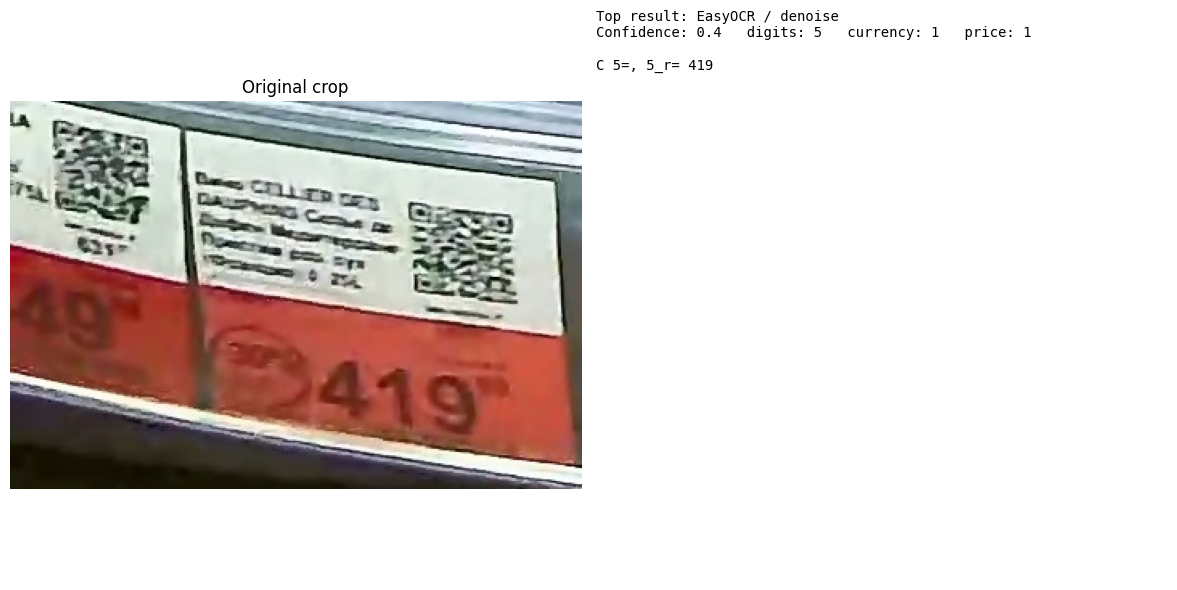

In [ ]:
# Примеры запуска Multi-OCR
# 1) Отобразить сводную таблицу и лучшее распознавание для одного crop
sample_crop = Path(CROPS_DIR) / 'frame_562_score_3254.9_bbox_731_3083_981_3266.jpg'
print(sample_crop.name)
show_crop_ocr_summary(sample_crop, top_n=7, methods=['original', 'clahe', 'adaptive_thresh', 'denoise', 'sharpen', 'upscale'], engines=['PaddleOCR', 'EasyOCR', 'pytesseract'])

# 2) Сравнить несколько вариантов OCR без просмотра картинки
# compare_ocr_outputs(sample_crop, top_n=12)
